In [ ]:
print("Car Damage Detection")

Car Damage Detection


In [ ]:
# Import necessary libraries
import os
import zipfile
import requests

# URL to your dataset zip file in the GitHub repository
dataset_url = 'https://raw.githubusercontent.com/rafdimilzano/data/main/cdadataset.zip'  # Change this URL to your dataset location

# Download the dataset
dataset_zip_path = 'cdadataset.zip'
response = requests.get(dataset_url)

# Save the zip file locally
with open(dataset_zip_path, 'wb') as file:
    file.write(response.content)

# Unzip the dataset
with zipfile.ZipFile(dataset_zip_path, 'r') as zip_ref:
    zip_ref.extractall('dataset')  # Extract the dataset into the 'dataset' folder

# Check the unzipped folder structure
os.listdir('dataset')


['validation', 'training']

In [ ]:
import os
import math
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random as python_random
import tensorflow as tf
import seaborn as sns
import math
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
from tensorflow.keras.callbacks import ModelCheckpoint
from  tensorflow.keras.callbacks import EarlyStopping
from keras import backend as K
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
# Set dataset paths
train_dir = 'dataset/training'    # Path to the Training set
val_dir = 'dataset/validation'    # Path to the Validation set
image_size = (190, 190)  # Resize images to 190x190
batch_size = 32

# Image augmentation for the training set to improve generalization
train_datagen = ImageDataGenerator(
    rescale=1.0/255,            # Rescale pixel values to [0, 1]
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# No augmentation for validation data, only rescaling
val_datagen = ImageDataGenerator(rescale=1.0/255)

# Loading training data from the structured directories
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)

# Loading validation data from the structured directories
validation_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)


Found 1383 images belonging to 3 classes.
Found 248 images belonging to 3 classes.


In [ ]:
# Loading VGG16 Model with Pre-trained Weights - without final (top) later as we will customize it
pre_trained_model = VGG16(weights='imagenet',
                          include_top=False,
                          classes = 3,
                          input_shape=(190, 190, 3))

In [ ]:
from tensorflow.keras import layers
num_classes = 3

for layer in pre_trained_model.layers:
            layer.trainable = False

last_output = pre_trained_model.output
x = layers.Flatten()(last_output)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
predictions = layers.Dense(num_classes, activation='softmax')(x)

vggmodel = tf.keras.models.Model(pre_trained_model.input, predictions)

vggmodel.compile(optimizer='adam', loss='CategoricalCrossentropy', metrics=['accuracy'])

vggmodel.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 190, 190, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 190, 190, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 190, 190, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 95, 95, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 95, 95, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 95, 95, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 47, 47, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 47, 47, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 47, 47, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 47, 47, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 23, 23, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 23, 23, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 23, 23, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 23, 23, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 11, 11, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 11, 11, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 11, 11, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 11, 11, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 5, 5, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 12800)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │       3,277,056 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 17,992,515 (68.64 MB)

 Trainable params: 3,277,827 (12.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# Try importing the callback from tensorflow.keras.callbacks
from tensorflow.keras.callbacks import EarlyStopping

# Define a callback to stop training when accuracy reaches a certain threshold
early_stopping = EarlyStopping(monitor='val_loss', patience=5, min_delta=0.005) #Example values for patience and min_delta

vgghist = vggmodel.fit(
    train_generator,
    steps_per_epoch=40,
    epochs=20,
    validation_data=validation_generator,
    validation_steps=10,
    callbacks=[early_stopping]
    )

Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


40/40 ━━━━━━━━━━━━━━━━━━━━ 677s 17s/step - accuracy: 0.4111 - loss: 2.7932 - val_accuracy: 0.7016 - val_loss: 0.7090
Epoch 2/20


/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


40/40 ━━━━━━━━━━━━━━━━━━━━ 197s 5s/step - accuracy: 0.5994 - loss: 0.8408 - val_accuracy: 0.7137 - val_loss: 0.7024
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 676s 17s/step - accuracy: 0.6330 - loss: 0.7897 - val_accuracy: 0.7218 - val_loss: 0.6842
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 154s 4s/step - accuracy: 0.5857 - loss: 0.8912 - val_accuracy: 0.6935 - val_loss: 0.7036
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 701s 17s/step - accuracy: 0.5991 - loss: 0.7906 - val_accuracy: 0.6976 - val_loss: 0.6712
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 163s 4s/step - accuracy: 0.5835 - loss: 0.8583 - val_accuracy: 0.7258 - val_loss: 0.6698
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 669s 17s/step - accuracy: 0.6509 - loss: 0.7450 - val_accuracy: 0.6935 - val_loss: 0.6687
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 163s 4s/step - accuracy: 0.6331 - loss: 0.7784 - val_accuracy: 0.7298 - val_loss: 0.6594
Epoch 9/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 737s 18s/step - accuracy: 0.7044 - loss: 0.7092 - val_accuracy: 0.7137 - val_loss

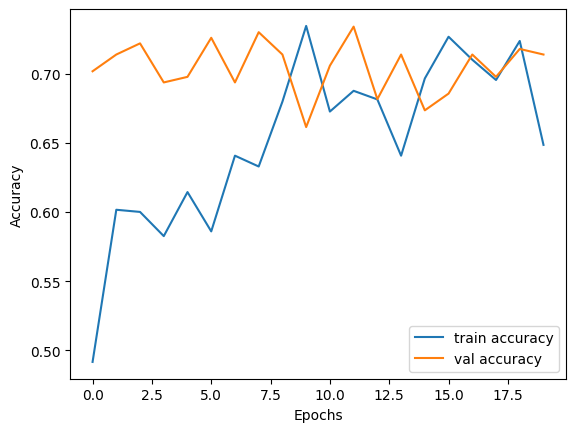

8/8 ━━━━━━━━━━━━━━━━━━━━ 121s 14s/step - accuracy: 0.7120 - loss: 0.6062
Validation Accuracy: 71.37%


In [ ]:
# Plot the training history for accuracy
plt.plot(vgghist.history['accuracy'], label='train accuracy')
plt.plot(vgghist.history['val_accuracy'], label='val accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Evaluate the model on validation data
val_loss, val_acc = vggmodel.evaluate(validation_generator)
print(f"Validation Accuracy: {val_acc*100:.2f}%")


In [ ]:
def classify_image(image_path, model):
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=image_size)
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0  # Scale the image

    prediction = model.predict(img_array)
    class_labels = ['Minor', 'Moderate', 'Severe']
    return class_labels[np.argmax(prediction)]

# Test classification
# test_image = 'path_to_test_image'
# classification = classify_image(test_image, model)
# print(f"Damage Severity: {classification}")
